In [1]:
import os, sys
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'

import pathlib


In [2]:
# Make repo root importable whether notebook is launched from /notebooks or repo root
cwd = pathlib.Path.cwd().resolve()

if (cwd / "src").exists():
    repo_root = cwd
elif (cwd.parent / "src").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(
        f"Could not find 'src' directory from {cwd}. "
        "Launch notebook from repo root or notebooks/."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)
print("Notebook cwd:", cwd)

Repo root: /projects/kumar-lab/USERS/chouda/unsupervised/KPMS/kp-moseq/kpms_combined_OFA/kpms_kumarlab
Notebook cwd: /projects/kumar-lab/USERS/chouda/unsupervised/KPMS/kp-moseq/kpms_combined_OFA/kpms_kumarlab/notebooks


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

import keypoint_moseq as kpms
from src.methods import load_and_format_data
from src.utils import load_config


In [4]:
# ── Paths ──────────────────────────────────────────────────────────────
project_dir = pathlib.Path("../results/combined_OFA_kappa_1e6")   # same as --project-path
pose_dir    = "/projects/kumar-lab/USERS/chouda/jabs/datasets/combined_ofa_dataset/combined_OFA/poses_csv_10k"            # same as --pose-dir
video_dir   = "/projects/kumar-lab/USERS/chouda/jabs/datasets/combined_ofa_dataset/combined_OFA/videos"           # same as --video-dir

# ── Model ──────────────────────────────────────────────────────────────
# Model name is the timestamp folder created during training, e.g. "2024_03_11-08_42_00"
model_name = "2025_11_11-12_23_15"

# ── Parameters ─────────────────────────────────────────────────────────
FPS           = 30       # must match your video framerate
MIN_FREQUENCY = 0.0001   # drop rare syllables below this threshold

# ── Load KPMS config (mirrors config_kpms lambda in training script) ──
config    = kpms.load_config(project_dir)
print("Loaded config:", config)


Loaded config: {'bodyparts': ['NOSE_INDEX', 'LEFT_EAR_INDEX', 'RIGHT_EAR_INDEX', 'BASE_NECK_INDEX', 'LEFT_FRONT_PAW_INDEX', 'RIGHT_FRONT_PAW_INDEX', 'CENTER_SPINE_INDEX', 'LEFT_REAR_PAW_INDEX', 'RIGHT_REAR_PAW_INDEX', 'BASE_TAIL_INDEX'], 'use_bodyparts': ['NOSE_INDEX', 'LEFT_EAR_INDEX', 'RIGHT_EAR_INDEX', 'BASE_NECK_INDEX', 'LEFT_FRONT_PAW_INDEX', 'RIGHT_FRONT_PAW_INDEX', 'CENTER_SPINE_INDEX', 'LEFT_REAR_PAW_INDEX', 'RIGHT_REAR_PAW_INDEX', 'BASE_TAIL_INDEX'], 'skeleton': [['BASE_TAIL_INDEX', 'RIGHT_REAR_PAW_INDEX'], ['BASE_TAIL_INDEX', 'LEFT_REAR_PAW_INDEX'], ['BASE_TAIL_INDEX', 'CENTER_SPINE_INDEX'], ['CENTER_SPINE_INDEX', 'LEFT_FRONT_PAW_INDEX'], ['CENTER_SPINE_INDEX', 'RIGHT_FRONT_PAW_INDEX'], ['CENTER_SPINE_INDEX', 'BASE_NECK_INDEX'], ['BASE_NECK_INDEX', 'NOSE_INDEX']], 'anterior_bodyparts': ['BASE_NECK_INDEX'], 'posterior_bodyparts': ['BASE_TAIL_INDEX'], 'added_noise_level': 0.1, 'PCA_fitting_num_frames': 1000000, 'conf_threshold': 0.5, 'error_estimator': {'intercept': 0.25, 'slop

In [5]:
# Re-use your existing load_and_format_data from src/methods.py
data, metadata, coordinates, confidences = load_and_format_data(pose_dir, project_dir)

# Load model results from {project_dir}/{model_name}/results.h5
results = kpms.load_results(project_dir, model_name)

print(f"Recordings loaded : {len(coordinates)}")
print(f"Syllables in results: {len(set(np.concatenate([r['syllable'] for r in results.values()])))}")


Loading keypoint files: 100%|█████████████████████████████████████████████████████████████████| 4494/4494 [01:43<00:00, 43.62it/s]


Recordings loaded : 4494
Syllables in results: 100


pre_frames = 5 post_frames = 15
Saving dendrogram plot to ../results/combined_OFA_kappa_1e6/2025_11_11-12_23_15/similarity_dendrogram


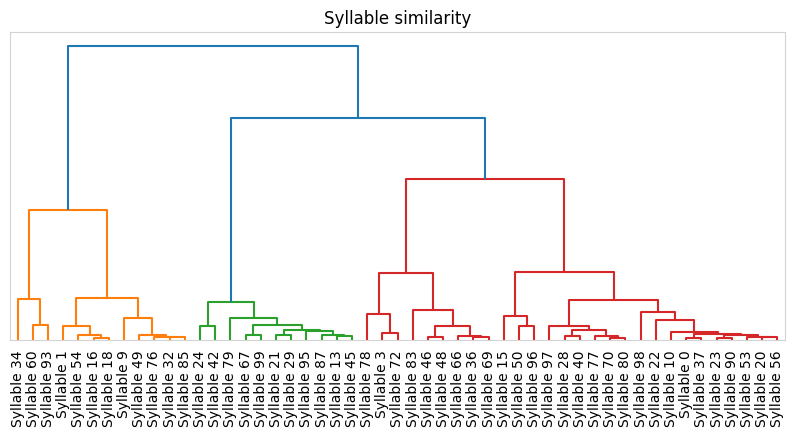

In [10]:
# ── 5A. Built-in dendrogram (saves PDF automatically) ─────────────────

# ---- choose window in seconds ----
pre_sec  = 0.167
post_sec = 0.5

MIN_FREQUENCY = 0.005 #0.5% motif usage 

# ---- convert to integer frames ----
pre_frames  = int(round(pre_sec * FPS))
post_frames = int(round(post_sec * FPS))

print("pre_frames =", pre_frames, "post_frames =", post_frames)

kpms.plot_similarity_dendrogram(
    coordinates   = coordinates,
    results       = results,
    project_dir   = project_dir,
    model_name    = model_name,
    metric        = "cosine",
    pre           = pre_frames,
    post          = post_frames,
    min_frequency = MIN_FREQUENCY,
    min_duration  = 3,
    figsize       = (10, 4),
)


# Saved to: {project_dir}/{model_name}/similarity_dendrogram.pdf




In [14]:
# ── 5B. Raw pairwise distance matrix from KPMS utility ─────────────────
dist_matrix, syllable_ixs = kpms.syllable_similarity(
    coordinates=coordinates,
    results=results,
    metric="cosine",
    pre=pre_frames,
    post=post_frames,
    min_frequency=0,
    min_duration=3,
    density_sample=False,
)

# cosine distance -> similarity
sim_matrix = 1.0 - dist_matrix

sim_df = pd.DataFrame(
    sim_matrix,
    index=syllable_ixs,
    columns=syllable_ixs,
)

dist_df = pd.DataFrame(
    dist_matrix,
    index=syllable_ixs,
    columns=syllable_ixs,
)






NameError: name 'save_dir' is not defined

In [15]:

save_dir = project_dir / model_name

sim_csv = save_dir / "syllable_similarity_matrix.csv"
dist_csv = save_dir / "syllable_distance_matrix.csv"

sim_df.to_csv(sim_csv)
dist_df.to_csv(dist_csv)

print(f"Saved similarity matrix to: {sim_csv}")
print(f"Saved distance matrix to: {dist_csv}")
print(f"Matrix shape: {sim_df.shape}")

display(sim_df.iloc[:5, :5])

Saved similarity matrix to: ../results/combined_OFA_kappa_1e6/2025_11_11-12_23_15/syllable_similarity_matrix.csv
Saved distance matrix to: ../results/combined_OFA_kappa_1e6/2025_11_11-12_23_15/syllable_distance_matrix.csv
Matrix shape: (99, 99)


,0,1,2,3,4
0,1.000000,0.577492,0.901723,0.736992,0.703663
1,0.577492,1.000000,0.679743,0.949810,0.308209
2,0.901723,0.679743,1.000000,0.799108,0.620462
3,0.736992,0.949810,0.799108,1.000000,0.437349
4,0.703663,0.308209,0.620462,0.437349,1.000000


In [18]:
np.nanmin(sim_matrix)

-0.27566995550421636

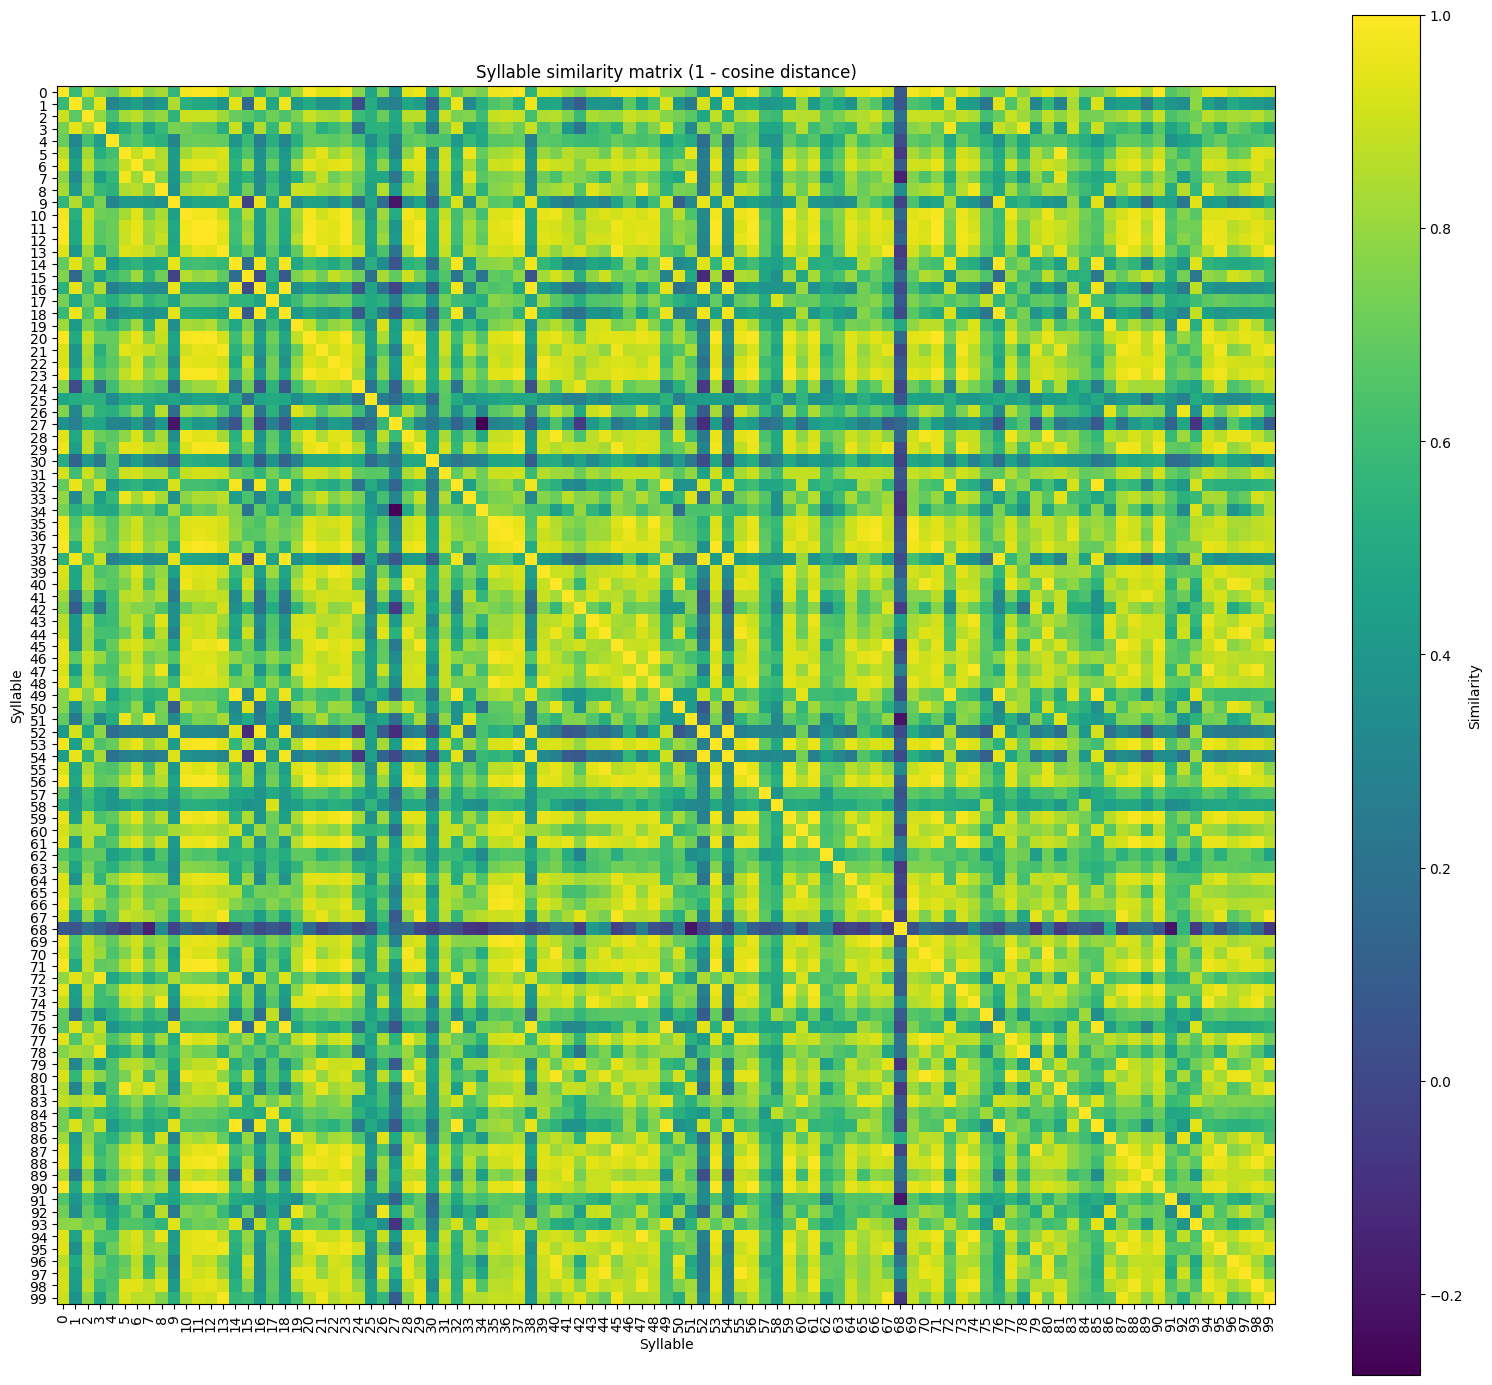

In [21]:
# ── 5C. Heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(sim_matrix, cmap="viridis", vmin=np.nanmin(sim_matrix), vmax=np.nanmax(sim_matrix))

ax.set_xticks(np.arange(len(syllable_ixs)))
ax.set_yticks(np.arange(len(syllable_ixs)))
ax.set_xticklabels(syllable_ixs, rotation=90)
ax.set_yticklabels(syllable_ixs)

ax.set_title("Syllable similarity matrix (1 - cosine distance)")
ax.set_xlabel("Syllable")
ax.set_ylabel("Syllable")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Similarity")

plt.tight_layout()
plt.savefig(save_dir / "syllable_similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()